# E-Commerce Sales Analytics
## Portfolio Project 1

**Stack:** Google BigQuery · Python (pandas, matplotlib, seaborn) · Tableau Public  

**Період:** 8.06.2026 - ...

**Мета:** Вивантажити, дослідити та статистично проаналізувати дані продажів інтернет-магазину, а потім візуалізувати ключові інсайти в інтерактивному дашборді Tableau.

If work locally - run this in terminal
gcloud auth application-default login
pip install google-cloud-bigquery
pip install db-dtypes
pip install matplotlib
pip install seaborn

In [78]:
from google.cloud import bigquery
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


os.environ.pop('GOOGLE_APPLICATION_CREDENTIALS', None)

try:
    from google.colab import auth
    
    auth.authenticate_user()
    print('Running in Google Colab')
    
except ModuleNotFoundError:
    print('Running locally in VS Code / Jupyter')
    print('Python:', sys.executable)

project_id = 'data-analytics-mate'
client = bigquery.Client(project=project_id)

print('BigQuery client created')

Running locally in VS Code / Jupyter
Python: /Users/apple/Documents/gitProjects/online_store_sales_analysis/.venv/bin/python


/Users/apple/Documents/gitProjects/online_store_sales_analysis/.venv/lib/python3.10/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


BigQuery client created


In [79]:
query = """
SELECT
  o.ga_session_id,        -- ідентифікатор сесії --
  o.item_id,              -- ідентифікатор товару --
  s.date,                 -- дата замовлення --
  sp.continent,           -- континент --
  sp.country,             -- країна --
  sp.device,              -- девайс --
  sp.browser,             -- браузер --
  sp.mobile_model_name,   -- назва моделі пристрою --
  sp.operating_system,    -- операційна система --
  sp.language,            -- мова браузера --
  sp.medium,              -- інформація про джерело трафіку --
  sp.channel,             -- канал трафіку --
  a_s.account_id,         -- дентифікатор зареєстрованого користувача --
  a.is_verified,          -- чи підтвердив користувач свій email --
  a.is_unsubscribed,      -- чи відписався користувач від розсилки --
  p.category,             -- категорія товару --
  p.name,                 -- назва товару --
  p.price,                -- ціна --
  p.short_description     -- короткий опис товару --
FROM `data-analytics-mate.DA.order` AS o
JOIN `data-analytics-mate.DA.session` AS s
  ON o.ga_session_id = s.ga_session_id
JOIN `data-analytics-mate.DA.session_params` AS sp
  ON o.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` AS a_s
  ON o.ga_session_id = a_s.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` AS a
  ON a_s.account_id = a.id
JOIN `data-analytics-mate.DA.product` AS p
  ON o.item_id = p.item_id
  """
df = client.query(query).to_dataframe()

/Users/apple/Documents/gitProjects/online_store_sales_analysis/.venv/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [80]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33538 entries, 0 to 33537
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ga_session_id      33538 non-null  Int64  
 1   item_id            33538 non-null  Int64  
 2   date               33538 non-null  dbdate 
 3   continent          33538 non-null  object 
 4   country            33538 non-null  object 
 5   device             33538 non-null  object 
 6   browser            33538 non-null  object 
 7   mobile_model_name  33538 non-null  object 
 8   operating_system   33538 non-null  object 
 9   language           22531 non-null  object 
 10  medium             33538 non-null  object 
 11  channel            33538 non-null  object 
 12  account_id         2781 non-null   Int64  
 13  is_verified        2781 non-null   Int64  
 14  is_unsubscribed    2781 non-null   Int64  
 15  category           33538 non-null  object 
 16  name               335

,ga_session_id,item_id,date,continent,country,device,browser,mobile_model_name,operating_system,language,medium,channel,account_id,is_verified,is_unsubscribed,category,name,price,short_description
0,7799937037,91415,2020-11-06,Europe,Slovakia,mobile,Chrome,<Other>,Web,fr,referral,Paid Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
1,4020421879,91415,2020-11-10,Americas,United States,desktop,Chrome,Safari,Macintosh,en,(none),Direct,653378,1,0,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
2,6717382496,91415,2020-11-24,Americas,United States,desktop,Chrome,Chrome,Web,en-us,referral,Social Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
3,2093497337,91415,2020-11-26,Americas,United States,desktop,Chrome,Chrome,Web,en-us,(none),Direct,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
4,9506718330,91415,2020-12-03,Europe,Spain,desktop,Chrome,ChromeBook,<Other>,en-us,referral,Paid Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"


In [81]:
unique_sessions = df['ga_session_id'].nunique()
date_min = df['date'].min()
date_max = df['date'].max()

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(0)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)

print(f'Унікальних сесій:   {unique_sessions:,}')
print(f'Дата від:           {date_min}')
print(f'Дата до:            {date_max}')
print()
print('Пропущені значення по колонках:')
print(missing_df)

Унікальних сесій:   33,538
Дата від:           2020-11-01
Дата до:            2021-01-27

Пропущені значення по колонках:
                 missing_count  missing_%
account_id               30757       92.0
is_verified              30757       92.0
is_unsubscribed          30757       92.0
language                 11007       33.0


# Короткий опис датасету

Датасет зібрано з BigQuery і є результатом з'єднання п'яти таблиць: замовлення (`order`), сесії (`session`), параметри сесій (`session_params`), акаунти (`account`) та товари (`product`). Кожен рядок відповідає одному проданому товару в межах однієї сесії.

---

## Загальна структура

| Параметр | Значення |
|---|---|
| Кількість рядків | 33 538 |
| Кількість колонок | 19 |
| Унікальних сесій | 33 538 *(кожна сесія - одна покупка)* |
| Часовий діапазон | 01.11.2020 - 27.01.2021 |
| Тривалість | ≈ 3 місяці *(Black Friday + Різдво + Новий рік)* |

---

## Типи колонок

### Числові - 6 колонок
| Колонка | Тип | Примітка |
|---|---|---|
| `ga_session_id` | Int64 | Ідентифікатор сесії (ключ) |
| `item_id` | Int64 | Ідентифікатор товару (ключ) |
| `account_id` | Int64 | ID зареєстрованого користувача |
| `is_verified` | Int64 | Бінарний прапор (0/1) |
| `is_unsubscribed` | Int64 | Бінарний прапор (0/1) |
| `price` | float64 | Ціна товару |

### Категоріальні - 12 колонок
`continent`, `country`, `device`, `browser`, `mobile_model_name`, `operating_system`, `language`, `medium`, `channel`, `category`, `name`, `short_description`

### Дата - 1 колонка
`date` (тип `dbdate`)

---

## Пропущені значення

| Колонка | Пропущено | % від усіх |
|---|---|---|
| `account_id` | 30 757 | **92%** |
| `is_verified` | 30 757 | **92%** |
| `is_unsubscribed` | 30 757 | **92%** |
| `language` | 11 007 | **33%** |

**Причини:**

- `account_id` / `is_verified` / `is_unsubscribed` - ці колонки підтягуються через `LEFT JOIN` до таблиці акаунтів. 92% покупок здійснено **незареєстрованими користувачами** - для них записів в таблиці `account` немає, тому всі три пов'язані поля `NULL`.

- `language` - мову браузера не вдалося визначити для 33% сесій.

---

## Елементи некоректних даних


In [82]:
print(df['mobile_model_name'].value_counts())

mobile_browser_diff = df.loc[df['mobile_model_name'] != df['browser'], ['mobile_model_name', 'browser']]

mobile_browser_diff.head(25)

mobile_model_name
Chrome        9359
Safari        6833
iPhone        6819
<Other>       6801
ChromeBook    1877
Edge           741
iPad           456
Firefox        430
Pixel 4 XL     117
Pixel 3        105
Name: count, dtype: int64


,mobile_model_name,browser
0,<Other>,Chrome
1,Safari,Chrome
4,ChromeBook,Chrome
6,iPhone,Safari
7,Safari,Chrome
10,<Other>,Chrome
11,Safari,Chrome
14,iPhone,Safari
15,iPhone,Safari
16,<Other>,Chrome


Під час перевірки даних було виявлено, що в колонці `mobile_model_name` частина значень - моделі пристроїв (`iPhone`, `iPad`, `Pixel 3`, `Pixel 4 XL`), також зустрічаються значення браузерів або платформ (`Chrome`, `Safari`, `Edge`, `Firefox`, `ChromeBook`).

Додаткова перевірка пари колонок `mobile_model_name` та `browser` показала, що ці поля не завжди дублюють одне одного. Наприклад, можуть зустрічатися комбінації `mobile_model_name = Safari` та `browser = Chrome`.

Це **очікувана поведінка GA4**, а не помилка даних. Поле `device_model` у GA4 фізично не збирається для Desktop-пристроїв. Тому для Desktop-рядків у `mobile_model_name` автоматично підставляється значення з браузерного user-agent. Комбінація `mobile_model_name = Safari` + `browser = Chrome` описує можливо браузер за замовчуванням у системі та фактично використаний браузер під час сесії.

Окремо: `ChromeBook` - це модель ноутбуку.

**Висновок щодо використання колонки:**
- `mobile_model_name` надійна лише для `device` mobile та tablet.
- Для Desktop-рядків містить назву браузера.

---

**Спостереження:** Датасет охоплює **святковий сезон** (листопад-січень), що безпосередньо впливає на обсяги продажів. 92% покупок - гостьові, що ускладнює персоналізований аналіз поведінки.

---
# Аналіз продажів

## 1. Географія продажів

In [141]:
continent_sales = df.groupby('continent')['price'].sum().sort_values(ascending=False)

print('Топ-3 континенти за сумою продажів (у доларах та % від загальної суми):')
for index, (continent, value) in enumerate(continent_sales.head(3).items(), start=1):
    print(f'{index}. {continent}: $ {value:,.0f} ({value / df["price"].sum() * 100:.1f}%)')

print('-'*80)
print()

continent_orders = df.groupby('continent')['ga_session_id'].nunique().sort_values(ascending=False)

print('Топ-3 континенти за кількістю замовлень (у сесіях та % від загальної кількості):')
for index, (continent, value) in enumerate(continent_orders.head(3).items(), start=1):
    print(f'{index}. {continent}: {value:,} замовлень ({value / unique_sessions * 100:.1f}%)')

print('-'*80)
print()

country_sales = df.groupby('country')['price'].sum().sort_values(ascending=False).head(5)

print('Топ-5 країн за сумою продажів (у доларах та % від загальної суми):')
for index, (country, value) in enumerate(country_sales.items(), start=1):
    print(f'{index}. {country}: $ {value:,.0f} ({value / df["price"].sum() * 100:.1f}%)')

print('-'*80)
print()

country_orders = df.groupby('country')['ga_session_id'].count().sort_values(ascending=False).head(5)

print('Топ-5 країн за кількістю замовлень (у сесіях та % від загальної кількості):')
for index, (country, value) in enumerate(country_orders.items(), start=1):
    print(f'{index}. {country}: {value:,} замовлень ({value / len(df) * 100:.1f}%)')

Топ-3 континенти за сумою продажів (у доларах та % від загальної суми):
1. Americas: $ 17,665,280 (55.3%)
2. Asia: $ 7,601,298 (23.8%)
3. Europe: $ 5,934,624 (18.6%)
--------------------------------------------------------------------------------

Топ-3 континенти за кількістю замовлень (у сесіях та % від загальної кількості):
1. Americas: 18,553 замовлень (55.3%)
2. Asia: 7,950 замовлень (23.7%)
3. Europe: 6,261 замовлень (18.7%)
--------------------------------------------------------------------------------

Топ-5 країн за сумою продажів (у доларах та % від загальної суми):
1. United States: $ 13,943,554 (43.6%)
2. India: $ 2,809,762 (8.8%)
3. Canada: $ 2,437,921 (7.6%)
4. United Kingdom: $ 938,318 (2.9%)
5. France: $ 710,693 (2.2%)
--------------------------------------------------------------------------------

Топ-5 країн за кількістю замовлень (у сесіях та % від загальної кількості):
1. United States: 14,673 замовлень (43.8%)
2. India: 3,029 замовлень (9.0%)
3. Canada: 2,560 зам

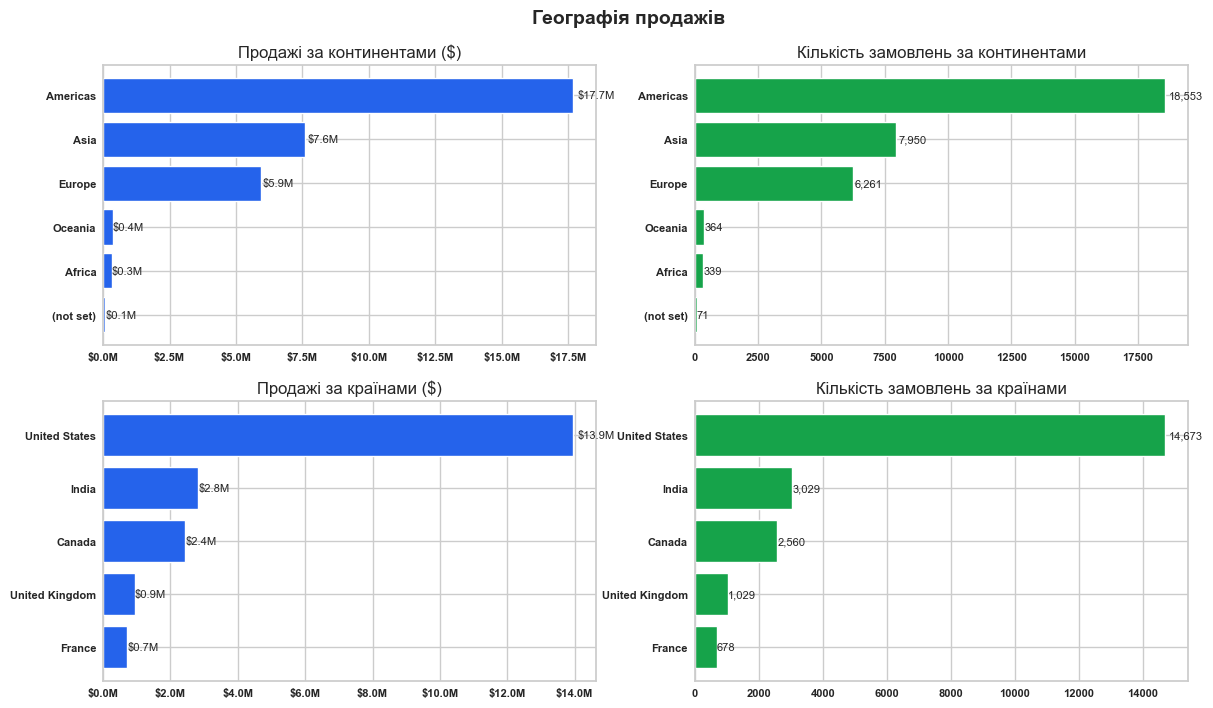

In [155]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})

ACCENT = '#2563EB'
GREEN  = '#16A34A'

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Географія продажів', fontsize=14, fontweight='bold', y=0.95)

# продажі за континентами
ax = axes[0, 0]
bars = ax.barh(continent_sales.index[::-1], continent_sales.values[::-1], color=ACCENT)
ax.set_title('Продажі за континентами ($)')

ax.tick_params(axis='x', labelsize=8, pad = -1)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
ax.tick_params(axis='y', labelsize=8, pad = -1)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for bar, val in zip(bars, continent_sales.values[::-1]):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'${val/1e6:.1f}M', va='center', fontsize=8)


# замовлення за континентами
ax = axes[0, 1]
bars = ax.barh(continent_orders.index[::-1], continent_orders.values[::-1], color=GREEN)
ax.set_title('Кількість замовлень за континентами')

ax.tick_params(axis='x', labelsize=8, pad = -1)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
ax.tick_params(axis='y', labelsize=8, pad = -1)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

for bar, val in zip(bars, continent_orders.values[::-1]):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)
    

# продажі за країнами
ax = axes[1, 0]
bars = ax.barh(country_sales.index[::-1], country_sales.values[::-1], color=ACCENT)
ax.set_title('Продажі за країнами ($)')

ax.tick_params(axis='x', labelsize=8, pad = -1)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
ax.tick_params(axis='y', labelsize=8, pad = -1)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for bar, val in zip(bars, country_sales.values[::-1]):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'${val/1e6:.1f}M', va='center', fontsize=8)
    

# замовлення за країнами
ax = axes[1, 1]
bars = ax.barh(country_orders.index[::-1], country_orders.values[::-1], color=GREEN)
ax.set_title('Кількість замовлень за країнами')

ax.tick_params(axis='x', labelsize=8, pad = -1)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
ax.tick_params(axis='y', labelsize=8, pad = -1)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

for bar, val in zip(bars, country_orders.values[::-1]):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)